<ins>Compute the principal components using the eigen vectors and values of the covariance matrix

In [1]:
def eig_PCA(X, keep_dims):

    import numpy as np

    #Center the data
    mean_X = np.mean(X, axis = 0)

    centered_X = X - mean_X



    #Compute the covariance matrix of the standardized matrix X


    number_of_features = X.shape[1]
    feature_means = np.mean(centered_X, axis = 0)
    cov_step_1 = centered_X - feature_means
    n = centered_X.shape[0]
    cov_X = np.zeros((20,20))


    for feature1 in range(number_of_features):
        for feature2 in range(number_of_features):
            #print(feature1)
            #print(feature2)
            cov_X[feature1,feature2] = (sum((cov_step_1[:,feature1]) * (cov_step_1[:,feature2]))) / (n-1)

        

    #Compute the eigen values and eigen vectors of the covariance matrix

    eigenvalues_cov_X, eigenvectors_cov_X = np.linalg.eig(cov_X)

    #Sort the eigenvalues and eigenvectors in descending eigenvalue order

    indeces_for_sorting = np.argsort(eigenvalues_cov_X)[::-1]
    sorted_eigenvalues_cov_X = eigenvalues_cov_X[indeces_for_sorting]
    sorted_eigenvectors_cov_X = eigenvectors_cov_X[indeces_for_sorting]

    #Project the standardized X matrix to the eigen vectors

    projected_data = np.dot(centered_X, sorted_eigenvectors_cov_X)

    #Compute the loadings of the features

    loadings = sorted_eigenvectors_cov_X * sorted_eigenvalues_cov_X

    #Compute the explained variance of each principal component
    explained_variance = sorted_eigenvalues_cov_X / sum(sorted_eigenvalues_cov_X)
    explained_variance[0] + explained_variance[1]


    return(projected_data[:,:keep_dims], loadings[:,:keep_dims], explained_variance[:keep_dims])






<ins>Compute the principal components using singulr value decomposition of the matrix

In [3]:
def svd_PCA(X, keep_dims):
    import numpy as np
    from matplotlib import pyplot as plt
    #SVD approach

    #Center the data

    mean_X = np.mean(X, axis = 0)
    std_X = np.std(X, axis = 0)
    centered_X = X - mean_X


    #SVD
    U, Sigma, VT = np.linalg.svd(centered_X)
    V = VT.T

   

    #Project the data
    svd_projected_data = np.dot(centered_X, V)

    #Compute the loadings
    n = centered_X.shape[0]
    svd_loadings = (V * Sigma) / (n-1)
    

    #compute the explained variance
    
    explained_variance = (Sigma * Sigma) / sum((Sigma * Sigma))

    
    
    return(svd_projected_data[:,:keep_dims], svd_loadings[:,:keep_dims], explained_variance[:keep_dims])



In [2]:
def PCA(data, keep_dims, method):
    if method == 'eig':
        result = eig_PCA(X=data, keep_dims = keep_dims)
        return(result)
        
    elif method == 'svd':
        result = svd_PCA(X=data, keep_dims = keep_dims)
        return(result)

    else:
        raise ValueError("Input Error. Method should be 'eig' or 'svd'")

<ins> Test the methods

In [4]:
#Generate data
from sklearn.datasets import make_blobs
#Cluster std = 1
X1, y1 = make_blobs(n_samples=1000,n_features=20,centers=3,cluster_std=1.0,random_state=78)
#Cluster std = 4
X2, y2 = make_blobs(n_samples=1000,n_features=20,centers=3,cluster_std=4.0,random_state=78)



In [5]:
all_explained_variances1 = PCA(X1, X1.shape[1], 'svd')[2]

cum_ev1 = []
for i, v in enumerate(all_explained_variances1):
    #print(i)
    cum_ev1.append(v + sum(all_explained_variances1[:i]))

all_explained_variances2 = PCA(X2, X2.shape[1], 'svd')[2]

cum_ev2 = []
for i, v in enumerate(all_explained_variances2):
    #print(i)
    cum_ev2.append(v + sum(all_explained_variances2[:i]))



<ins> Plot the explained variance

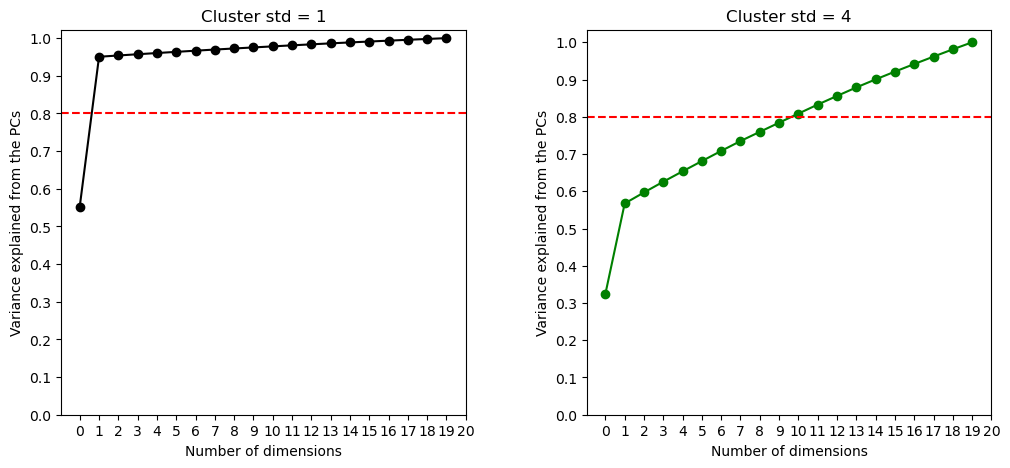

In [7]:
from matplotlib import pyplot as plt

x1 = cum_ev1
x2 = cum_ev2

fig, (ax1, ax2) = plt.subplots(1,2, figsize = (12,5))

ax1.plot(cum_ev1, c = 'black', marker = 'o')
ax1.axhline(y=0.8, color='r', linestyle='--', label='90 percent of the data variance')
#ax1.set_xlim(0, 1)
ax1.set_xticks(list(range(0,21)))
ax1.set_yticks([i * 0.1 for i in range(11)])
ax1.set_xlabel('Number of dimensions')
ax1.set_ylabel('Variance explained from the PCs')
ax1.set_title('Cluster std = 1')

###############################

ax2.plot(cum_ev2, c = 'green', marker = 'o')
ax2.axhline(y=0.8, color='r', linestyle='--', label='90 percent of the data variance')
#ax2.set_xlim(0, 1)
ax2.set_xticks(list(range(0,21)))
ax2.set_yticks([i * 0.1 for i in range(11)])
ax2.set_xlabel('Number of dimensions')
ax2.set_ylabel('Variance explained from the PCs')
ax2.set_title('Cluster std = 4')

plt.subplots_adjust(wspace=0.3)

plt.show()








<ins> Plot the first two principal components

[]

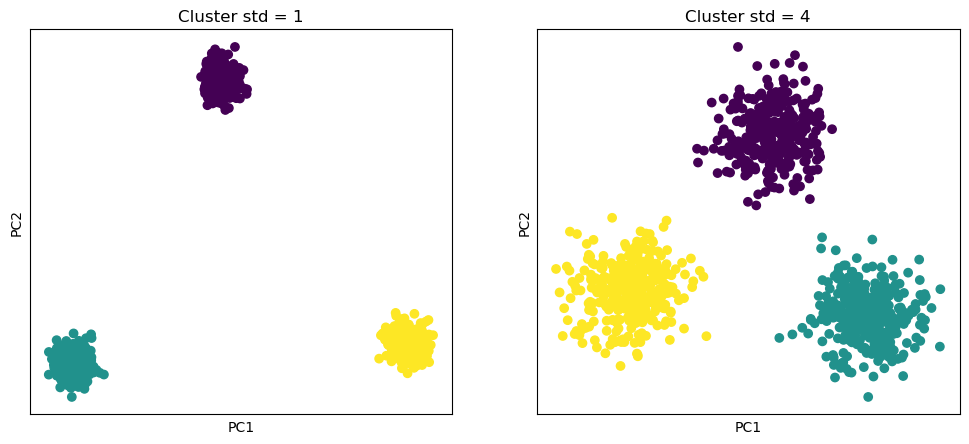

In [8]:
#Plot the first 2 principal components
pc1_2_1 = PCA(X1, 2, 'svd')[0]
pc1_2_2 = PCA(X2, 2, 'svd')[0]


fig, (ax1, ax2) = plt.subplots(1,2, figsize = (12, 5))

ax1.scatter(pc1_2_1[:,0],pc1_2_1[:,1], c = y1)
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_title('Cluster std = 1')
ax1.set_xticks([])
ax1.set_yticks([])

ax2.scatter(pc1_2_2[:,0],pc1_2_2[:,1], c = y2)
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_title('Cluster std = 4')
ax2.set_xticks([])
ax2.set_yticks([])


#plt.show()

## <ins> Plot the loadings  of the features or the first two principal components


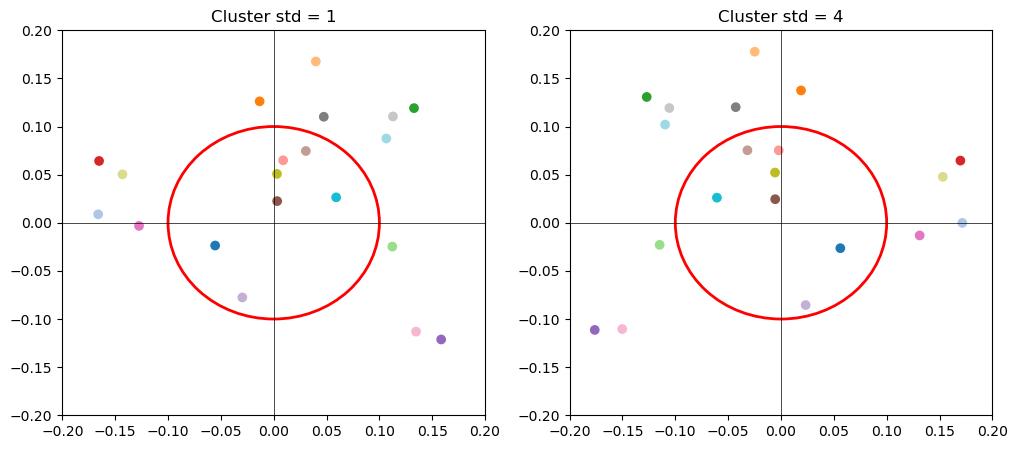

In [9]:
from matplotlib.patches import Circle
loadings_pc1_2_1 = PCA(X1, 2, 'svd')[1]
loadings_pc1_2_2 = PCA(X2, 2, 'svd')[1]

cmap = plt.get_cmap('tab20')

my_colors = [cmap(i) for i in range(20)]


fig, (ax1, ax2) = plt.subplots(1,2, figsize = (12, 5))

ax1.scatter(loadings_pc1_2_1[:,0],loadings_pc1_2_1[:,1], c = my_colors)
ax1.set_title('Cluster std = 1')
ax1.set_xlim(-0.2, +0.2)
ax1.set_ylim(-0.2, +0.2)
#ax1.set_xticks([])
#ax1.set_yticks([])
ax1.axhline(0, color='black', linewidth=0.5)
ax1.axvline(0, color='black', linewidth=0.5)
circle1 = Circle((0, 0), radius=0.1, edgecolor='red', facecolor='none', linewidth=2)
ax1.add_patch(circle1)


ax2.scatter(loadings_pc1_2_2[:,0],loadings_pc1_2_2[:,1], c = my_colors)
ax2.set_title('Cluster std = 4')
ax2.set_xlim(-0.2, +0.2)
ax2.set_ylim(-0.2, +0.2)
#ax2.set_xticks([])
#ax2.set_yticks([])
ax2.axhline(0, color='black', linewidth=0.5)
ax2.axvline(0, color='black', linewidth=0.5)
circle2 = Circle((0, 0), radius=0.1, edgecolor='red', facecolor='none', linewidth=2)
ax2.add_patch(circle2)
